### Anomaly Detection And Risk Scoring

This notebook validates engineered behavioural risk features on synthetic transaction data. The goal is to assess whether high-risk signals meaningfully differentiate anomalous transactions from normal activity.

In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Load the data

In [ ]:
try:
  df=pd.read_csv('/data/processed/transaction_features.csv')
  print(f'Successfully loaded the data {df.shape} ')
except Exception as e:
  print(f'Error loading the data {e}')

Successfully loaded the data (40543, 19) 


In [56]:
# Ensure timestamp is datetime
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")

# Quick sanity checks
print(df["timestamp"].dtype)
print("NaT (failed parses):", df["timestamp"].isna().sum())
print("Min/Max:", df["timestamp"].min(), df["timestamp"].max())

datetime64[ns]
NaT (failed parses): 0
Min/Max: 2021-05-07 13:39:16.458439953 2026-02-16 00:00:00


In [57]:
df = df.dropna(subset=["timestamp"]).copy()



Basic QA



In [58]:
print("Duplicate transaction IDs:", df["transaction_id"].duplicated().sum())

Duplicate transaction IDs: 0


In [59]:
print("Rows:", len(df))
print("Users:", df["user_id"].nunique())
print("Anomaly rate:", df["is_anomaly"].mean())

Rows: 40543
Users: 2000
Anomaly rate: 0.04279407049305675


In [60]:
print("\nMissing values:")
print(df.isna().mean().sort_values(ascending=False).head())


Missing values:
anomaly_type           0.957206
time_since_prev_min    0.049330
prev_city              0.049330
timestamp              0.000000
user_id                0.000000
dtype: float64


Distribution of Transaction Amounts

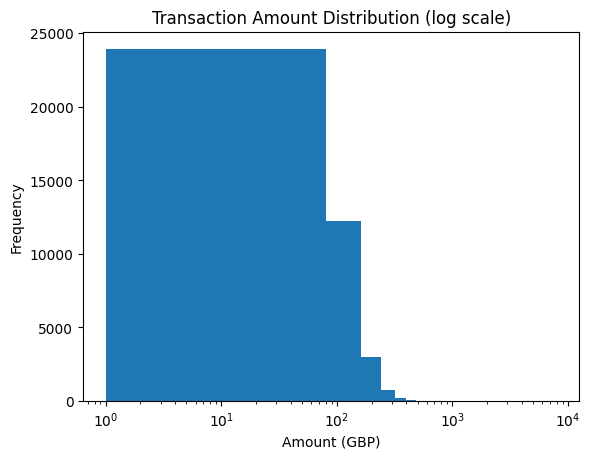

In [61]:
plt.hist(df["amount_gbp"], bins=100)
plt.xscale("log")
plt.title("Transaction Amount Distribution (log scale)")
plt.xlabel("Amount (GBP)")
plt.ylabel("Frequency")
plt.show()

Do anomalies have higher risk scores?

In [62]:
df.groupby("is_anomaly")["risk_score"].describe()

,count,mean,std,min,25%,50%,75%,max
is_anomaly,,,,,,,,
0,38808.0,0.937616,1.283062,0.0,0.0,0.0,2.0,7.0
1,1735.0,2.903170,1.421481,0.0,2.0,3.0,3.0,8.0


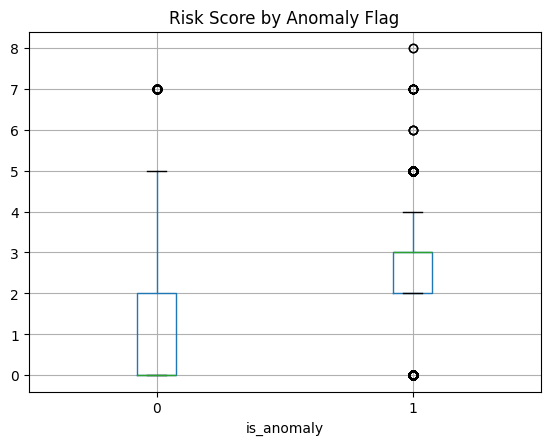

In [63]:
df.boxplot(column="risk_score", by="is_anomaly")
plt.title("Risk Score by Anomaly Flag")
plt.suptitle("")
plt.show()

Feature Behaviour Comparison

In [64]:
df.groupby("is_anomaly")["is_night_tx"].mean()*100

,is_night_tx
is_anomaly,
0,25.456092
1,28.818444


Velocity Comparison

In [65]:
df.groupby("is_anomaly")["tx_count_10min"].mean()

,tx_count_10min
is_anomaly,
0,1.005360
1,2.905476


Risk Band effectiveness

In [66]:
band_summary = df.groupby("risk_band").agg(
    transactions=("transaction_id", "count"),
    anomaly_rate=("is_anomaly", "mean"),
    avg_score=("risk_score", "mean")
).sort_values("avg_score", ascending=False)

band_summary

,transactions,anomaly_rate,avg_score
risk_band,,,
High,82,0.243902,6.975610
Medium,4290,0.289277,3.737529
Low,36171,0.013104,0.686130


Time Trend of Anomalies

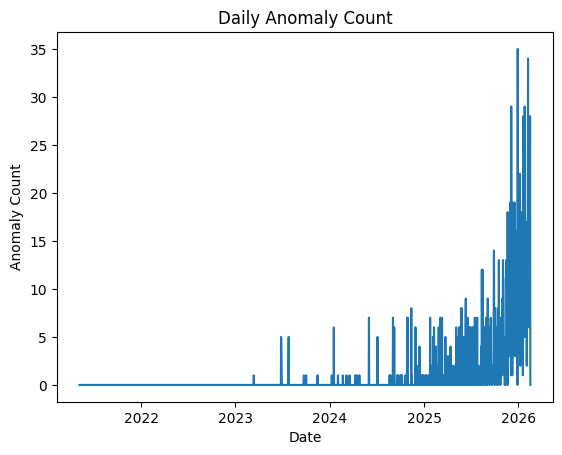

In [67]:
daily = df.groupby(df["timestamp"].dt.date)["is_anomaly"].sum()
daily.plot()
plt.title("Daily Anomaly Count")
plt.xlabel("Date")
plt.ylabel("Anomaly Count")
plt.show()

In [68]:
high_anom_rate = band_summary.loc["High", "anomaly_rate"] * 100 if "High" in band_summary.index else None
high_tx = band_summary.loc["High", "transactions"] if "High" in band_summary.index else None
high_anom_rate, high_tx

(np.float64(24.390243902439025), np.int64(82))

## Key Findings


*   Anomalies have ~3x higher mean risk_score than normal transactions.
*   Velocity (tx_count_10min) is the strongest separating signal in this synthetic setup.
*  High risk band captures 24.39% anomaly rate across 82 transactions, consider tuning band thresholds if Medium > High.




